In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hdbscan import HDBSCAN
from pathlib import Path
from common.data import DataWithLabels

import torch 
import numpy as np

from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR


In [17]:
dataset = DataWithLabels.from_npz(r'data/monte_carlo_configs.npz')

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels


## Contrastive Learning

In [18]:
from metric_learning.dataset import make_balanced_train_test_dataset

vectors = torch.from_numpy(X).float()
vectors = torch.nn.functional.normalize(vectors, dim=1)

sims = []
for i in range(len(vectors)):
    dot = torch.matmul(vectors[i], vectors.t()) # cos for all vectors with i-th vector
    sims.append(dot)

sims = torch.cat(sims) 
COS_MIN_GLOBAL = sims.min().item()
COS_MAX_GLOBAL = sims.max().item()


Epoch 1/200, Average Loss: 0.180442, Average Val Loss: 0.169183
Epoch 2/200, Average Loss: 0.169566, Average Val Loss: 0.134312
Epoch 3/200, Average Loss: 0.154950, Average Val Loss: 0.139393
Epoch 4/200, Average Loss: 0.150280, Average Val Loss: 0.120450
Epoch 5/200, Average Loss: 0.145691, Average Val Loss: 0.115304
Epoch 6/200, Average Loss: 0.140842, Average Val Loss: 0.112106
Epoch 7/200, Average Loss: 0.133512, Average Val Loss: 0.109543
Epoch 8/200, Average Loss: 0.129011, Average Val Loss: 0.107872
Epoch 9/200, Average Loss: 0.123848, Average Val Loss: 0.100669


c:\Users\Vít\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 10/200, Average Loss: 0.121723, Average Val Loss: 0.101099
Epoch 11/200, Average Loss: 0.117982, Average Val Loss: 0.098169
Epoch 12/200, Average Loss: 0.114944, Average Val Loss: 0.095348
Epoch 13/200, Average Loss: 0.111474, Average Val Loss: 0.091041
Epoch 14/200, Average Loss: 0.108421, Average Val Loss: 0.089968
Epoch 15/200, Average Loss: 0.105842, Average Val Loss: 0.088124
Epoch 16/200, Average Loss: 0.104189, Average Val Loss: 0.087155
Epoch 17/200, Average Loss: 0.101941, Average Val Loss: 0.085755
Epoch 18/200, Average Loss: 0.098973, Average Val Loss: 0.084038
Epoch 19/200, Average Loss: 0.097574, Average Val Loss: 0.082322
Epoch 20/200, Average Loss: 0.096780, Average Val Loss: 0.081398
Epoch 21/200, Average Loss: 0.093242, Average Val Loss: 0.079747
Epoch 22/200, Average Loss: 0.091754, Average Val Loss: 0.077617
Epoch 23/200, Average Loss: 0.091128, Average Val Loss: 0.076091
Epoch 24/200, Average Loss: 0.088328, Average Val Loss: 0.073556
Epoch 25/200, Average Los

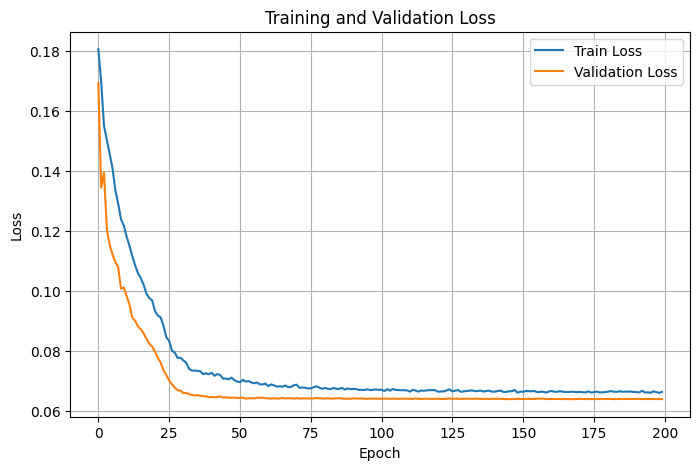

Embeddings shape: (6000, 3)


In [19]:
from metric_learning.losses import continuous_contrastive_loss, Q_distance
from functools import partial
from metric_learning.model import Embedder,TrainConfig, train_model, get_embeddings
from common.utils import plot_loss_curves

save_dir = Path('models')
save_dir.mkdir(exist_ok=True)

BATCH_SIZE = 128
NUM_EPOCHS = 200
LEARNING_RATE = 3e-4
EMBEDDING_SIZE = 3
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, test_loader = make_balanced_train_test_dataset(
                                Configurations, X, 
                                batch_size=BATCH_SIZE, 
                                train_ratio=0.8, 
                            )
train = True
save_model = True
if train:
    model = Embedder(embedding_size=EMBEDDING_SIZE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # warmup epochs
    warmup_epochs = max(1, int(0.05 * NUM_EPOCHS))
    sched1 = LinearLR(optimizer, start_factor=1e-2, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(NUM_EPOCHS - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])


    loss_function = partial(continuous_contrastive_loss,mu=1.0, ms_mining=True)

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_function=loss_function,
        Q_distance=partial(Q_distance, c_min = COS_MIN_GLOBAL, c_max = COS_MAX_GLOBAL),
        train_loader=train_loader,
        test_loader=test_loader,
    )

    avg_loss, avg_val_loss = train_model(config, num_epochs=NUM_EPOCHS)
    plot_loss_curves(avg_loss, avg_val_loss)

    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'embedder.pt')
else:
    checkpoint = torch.load(save_dir / 'embedder.pt', map_location=device, weights_only=True)

    model = Embedder(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")


### Clustering of Monte Carlo embeddings

here, we shall cluster samples in the embedding space and compare to the original clustering.

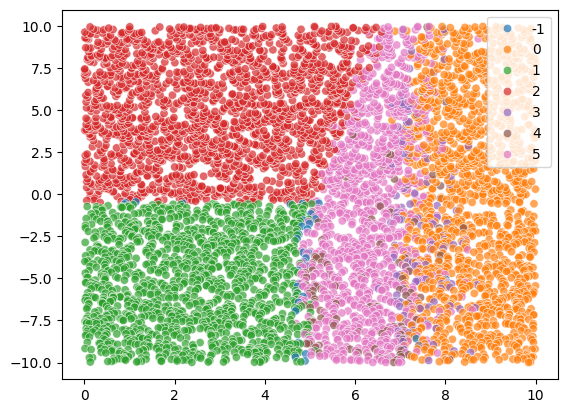

In [20]:
hd_contr = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.016, cluster_selection_method='eom').fit(all_embeddings)
Labels_contr = hd_contr.labels_

ax = sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels_contr, palette='tab10', alpha=0.7)

### Optimized configurations and clustering

In [21]:
data_grad = DataWithLabels.from_npz('data/optimized_configs.npz')
embeddings_grad = get_embeddings(config, data_grad.configurations)

<Axes: >

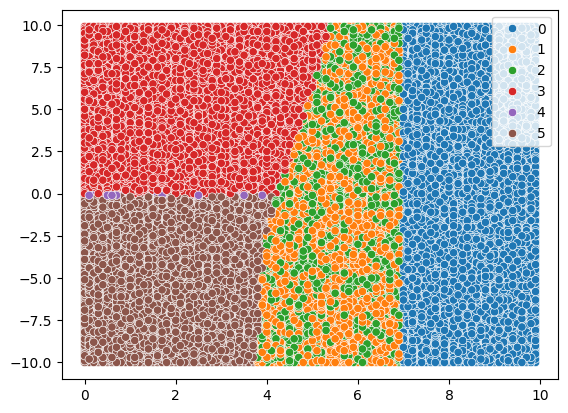

In [26]:
hd_grad = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.01, cluster_selection_method='eom').fit(embeddings_grad)
Labels_grad = hd_grad.labels_

Values_grad = data_grad.values
sns.scatterplot(x=Values_grad[:, 1], y=Values_grad[:, 0], hue=Labels_grad, palette='tab10')

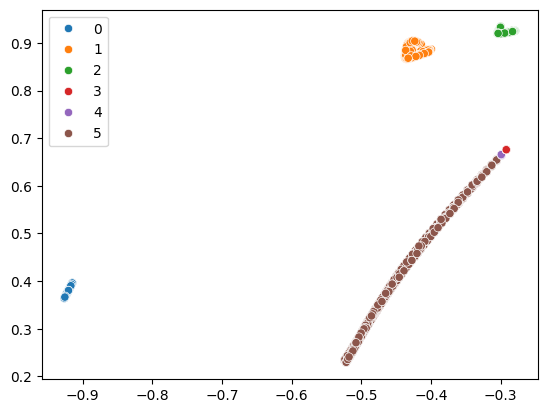

<Axes: >

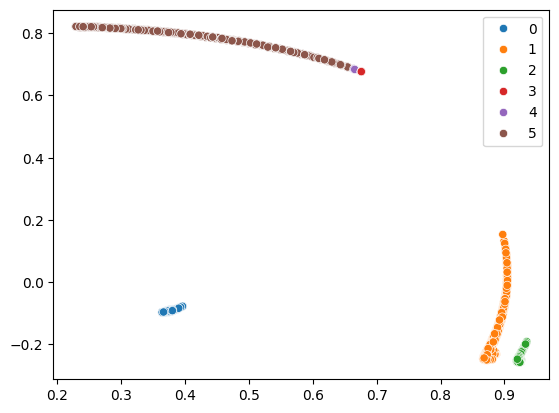

In [27]:
sns.scatterplot(x=embeddings_grad[:, 0], y=embeddings_grad[:, 1], hue=Labels_grad, palette='tab10')
plt.show()
sns.scatterplot(x=embeddings_grad[:, 1], y=embeddings_grad[:, 2], hue=Labels_grad, palette='tab10')